In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2025-01-09 20:57:11.018334: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-09 20:57:11.022529: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-09 20:57:11.035307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736452631.058970  173497 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736452631.067863  173497 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-09 20:57:11.090129: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [5]:
# Step 1: Load and Clean Data
file_path = 'Cleaned_dataset.csv'  # Update this path if needed
data = pd.read_csv(file_path)

In [7]:
# Drop unnecessary columns
columns_to_remove = ['Title', 'Tags', 'Tags_length', 'Localisation', 'Latitude', 'Longitude', 'Floor']
data_cleaned = data.drop(columns=columns_to_remove)

In [9]:
# Filter rows with valid price range
lower_bound = 50000
upper_bound = 10000000
data_cleaned = data_cleaned[(data_cleaned['Price in DH'] >= lower_bound) & 
                            (data_cleaned['Price in DH'] <= upper_bound)]

In [11]:
# Encode categorical variables
data_cleaned = pd.get_dummies(data_cleaned, columns=['Type', 'Condition'], drop_first=True)

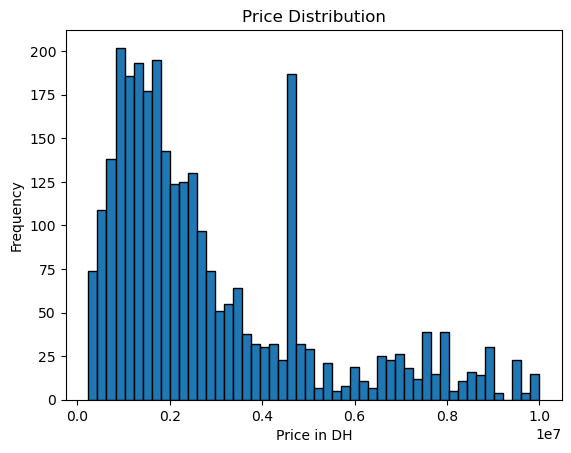

In [13]:
# Step 2: Analyze Price Distribution
plt.hist(data_cleaned['Price in DH'], bins=50, edgecolor='k')
plt.title('Price Distribution')
plt.xlabel('Price in DH')
plt.ylabel('Frequency')
plt.show()

In [15]:
# Calculate IQR
Q1 = data_cleaned['Price in DH'].quantile(0.25)
Q3 = data_cleaned['Price in DH'].quantile(0.75)
IQR = Q3 - Q1
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

In [17]:
# Filter data based on IQR
data_filtered = data_cleaned[(data_cleaned['Price in DH'] >= lower_bound_iqr) & 
                              (data_cleaned['Price in DH'] <= upper_bound_iqr)]

In [19]:
# Step 3: Prepare Data
X = data_filtered.drop(columns=['Price in DH'])
y = data_filtered['Price in DH']

In [21]:
# Log-transform the target variable
y_log = np.log1p(y)  # log(1 + price)

In [23]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.1, random_state=42)

In [25]:
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Step 4: Build and Train the Neural Network
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

/home/am44/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-01-09 20:59:06.209252: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [29]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [31]:
# Train the model
history = model.fit(X_train_scaled, y_train, 
                    validation_data=(X_test_scaled, y_test), 
                    epochs=100, batch_size=32, verbose=1)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 148.9015 - mae: 11.5880 - val_loss: 8.9584 - val_mae: 2.5187
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.0529 - mae: 2.1293 - val_loss: 2.2101 - val_mae: 1.1537
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5488 - mae: 1.0919 - val_loss: 1.0095 - val_mae: 0.7249
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3504 - mae: 0.7916 - val_loss: 0.6331 - val_mae: 0.5679
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6918 - mae: 0.6037 - val_loss: 0.4433 - val_mae: 0.4725
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4407 - mae: 0.4761 - val_loss: 0.3441 - val_mae: 0.4109
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3318 - mae: 0.4313 - val_loss: 0.3195 - val_mae: 0.3940
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2918 - mae: 0.3917 - val_loss: 0.2843 - val_mae: 0.3681
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

In [33]:
# Step 5: Evaluate the Model
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.2f}")
print(f"Test Mean Absolute Error (MAE): {test_mae:.2f}")

# Step 6: Test Custom Input
# Example custom input (replace with actual values)
custom_input = [[120, 5, 3, 2, 7, 1, 0, 0, 0, 1]]  # Example: Replace with valid values
custom_input_scaled = scaler.transform(custom_input)
predicted_log = model.predict(custom_input_scaled)
predicted_price = np.expm1(predicted_log)  # Reverse the log1p transform
print(f"Predicted Price: {predicted_price[0][0]:.2f} DH")

Test Loss (MSE): 0.23
Test Mean Absolute Error (MAE): 0.34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Price: 5247381.00 DH


/home/am44/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
